# E2 — MoG40 (2D)

**Target.** $V(x) = -\tfrac1\beta\log\sum_{k=1}^{40} e^{-\|x-\mu_k\|^2/2}$, so $\pi\propto e^{-\beta V}$ is an equal-weight mixture of $\mathcal N(\mu_k, I_2)$ (the $1/\beta$ prefactor is what makes the barriers right: $\beta\Delta V = d^2/8-\log 2$ between modes at distance $d$). Modes $\mu_k\sim\mathrm{Unif}([-40,40]^2)$, frozen from `default_rng(0)`. All particles start at $\mu_0+0.5\,\xi$; partition = nearest-mode Voronoi, $p^\star_k = 1/40$.

In [1]:
EXPERIMENT = "mog40"
import os, sys, math, time, json
sys.path.insert(0, os.path.abspath(".."))
from src.gpu_guard import select_gpu
select_gpu(int(os.environ.get("JCP_GPU", "4")))
import torch
assert torch.cuda.device_count() == 1
torch.set_default_dtype(torch.float64)
import numpy as np
import pandas as pd

from src import config as C
from src.experiments import (build_e2, make_sampler_factory,
                             make_batched_factory, make_metrics)
from src.runner import (run_experiment_batched, run_one, refine_dt,
                        quadrature_refinement, write_timeseries_csv,
                        write_summary_csv, write_manifest,
                        ula_first_passage, hardware_manifest)
from src.samplers import tune_ladder
from src.certificate import make_phi_family, certificate_grid, certificate_importance
from src.plotting import metric_grid

DEV = "cuda"
RESULTS = os.path.abspath(os.path.join("..", "results", EXPERIMENT))
FIGURES = os.path.abspath(os.path.join("..", "figures", EXPERIMENT))
os.makedirs(RESULTS, exist_ok=True); os.makedirs(FIGURES, exist_ok=True)
exp = build_e2(device=DEV)
cfg = exp.cfg
# method matrix: default = the 7 exact methods; override with JCP_METHODS (comma-
# separated) e.g. run_production.sh sets E1/E2 = exact + RA dual-run, E3/E4 = RA.
RUN_METHODS = os.environ.get("JCP_METHODS", ",".join(C.METHODS)).split(",")
print(f"experiment={cfg.name}  d={cfg.d}  N={cfg.n_particles}  T={cfg.T}  dt0={cfg.dt}")
print(f"beta={cfg.beta}  eps={cfg.eps}  lambda={cfg.lam}  seeds={cfg.seeds}")
print("RUN_METHODS:", RUN_METHODS)
print(hardware_manifest())

experiment=mog40  d=2  N=2500  T=100.0  dt0=0.01
beta=8.0  eps=0.125  lambda=1.0  seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)
RUN_METHODS: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP', 'LSC-CP-RA']


{'cpu': 'AMD EPYC 9554 64-Core Processor', 'gpu': 'NVIDIA H200 NVL', 'torch': '2.13.0+cu130', 'cuda': '13.0', 'python': '3.12.13', 'git_sha': '81a24d30aefb51ee5d73f3bec51fa05a6cc45b65', 'cuda_visible_devices': '0', 'gpu_compute_apps_at_start': ['GPU-514c2f3b-34cc-98a9-dfa1-7671c8c08767, 467174, 710 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 4103055, 814 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 4154265, 7588 MiB', 'GPU-b7477750-5992-8ae3-fde2-11bf70934062, 119782, 67232 MiB']}


In [2]:
np.savetxt(os.path.join(RESULTS, "modes.csv"), exp.pot.mu.cpu().numpy(),
           delimiter=",", header="mu_x,mu_y", comments="")
dists = torch.cdist(exp.pot.mu, exp.pot.mu); dists.fill_diagonal_(float("inf"))
nn = dists.min(dim=1).values.cpu().numpy()
print(f"NN distances: min {nn.min():.2f} median {np.median(nn):.2f} max {nn.max():.2f}"
      "  -> jump radii Unif[4, 15] chosen from this histogram alone")
g = torch.Generator(device=DEV); g.manual_seed(0)
barrier_report = ula_first_passage(exp.pot, exp.box, exp.init_fn(cfg.n_particles, g),
                                   exp.exit_committed, cfg.dt, int(cfg.T/cfg.dt), C.EPS, g)
barrier_report["kramers_tau_mode0"] = exp.kramers_tau
print(f"ULA committed MFPT {barrier_report['mfpt_estimate']:.0f} vs Kramers "
      f"{exp.kramers_tau:.0f}")

NN distances: min 1.22 median 6.78 max 16.02  -> jump radii Unif[4, 15] chosen from this histogram alone


ULA committed MFPT 1664 vs Kramers 552


## Jump law and Lévy score (closed form)

Deliberately generic annulus law — $r=\rho u_\phi$, $\rho\sim\mathrm{Unif}[4,15]$, $\phi\sim\mathrm{Unif}[0,2\pi)$ — **neither PT nor LSC-CP receives mode locations**. For the Gaussian mixture the $\theta$ and $\rho$ integrals of the score are analytic: with $m_{k\ell}=u_\ell\cdot(x-\mu_k)$,
$$S(x) = -\frac{\lambda}{M_\phi(b-a)}\sum_\ell u_\ell \sum_k e^{\log\omega_k + m_{k\ell}^2/2}\,\sqrt{\tfrac\pi2}\,\mathcal B(m_{k\ell}),$$
with $\mathcal B(m) = F(b\!-\!m)-F(a\!-\!m)+(b\!-\!a)\,\mathrm{erf}(m/\sqrt2)>0$ and $F(z)=z\,\mathrm{erf}(z/\sqrt2)+\sqrt{2/\pi}e^{-z^2/2}$, evaluated by outer-regime branches in which the $O(m)$ parts cancel *analytically* (the naive form has 100% error at $m=30$; the branched form is validated against 3000-digit mpmath and a brute-force 3-D quadrature at $10^{-8}$). Only the periodic $\phi$-trapezoid ($M_\phi$ directions) is numerical — **zero potential evaluations**.

In [3]:
DEFAULT_QUAD = dict(m_phi=C.M_PHI)
phis = make_phi_family(2, [0.0, 0.0], 30.0, DEV)

def cert_e2(m_phi):
    score = exp.make_score(m_phi=m_phi)
    shifts, logw = exp.law.quadrature_shifts(16, 64)
    return certificate_grid(exp.pot, score, shifts, logw, cfg.lam, cfg.beta,
                            phis, [-60.0, -60.0], [60.0, 60.0],
                            n_panels=120, nodes_per_panel=6, chunk=8192)

cert_report = cert_e2(**DEFAULT_QUAD)
print(f"max R = {cert_report['max_residual']:.3e}")
assert cert_report["max_residual"] < 1e-6

max R = 7.817e-13


In [4]:
# PT: geometric ladder beta_k = beta * r^(k-1); K tuned so the post-burn-in
# swap acceptance lands in [0.2, 0.4]
gen = torch.Generator(device=DEV); gen.manual_seed(0)
x0_pilot = exp.init_fn(min(512, cfg.n_particles), gen)
pt_betas, ladder_info = tune_ladder(exp.pot, x0_pilot, cfg.dt, exp.box,
                                    cfg.beta, exp.pt_beta_min, pilot_steps=20_000)
print(f"PT ladder: K={ladder_info['K']}  r={ladder_info['r']:.4f}  "
      f"beta_K={pt_betas[-1].item():.4f}  swap acceptance={ladder_info['swap_acceptance']:.3f}"
      f"  band_attained={ladder_info['band_attained']}")

PT ladder: K=3  r=0.0559  beta_K=0.0250  swap acceptance=0.262  band_attained=True


In [5]:
# frozen reference sample (size N), frozen sliced-W2 projections, frozen MMD
# bandwidth (median heuristic on the reference); bias floors from 20
# independent reference pairs. EMC convention: exp(H(p_hat))/K for uniform
# p*, 1 - EJS(p_hat, p*) otherwise -- near 1 is better in both cases.
metrics_fn, floors, aux = make_metrics(exp, cfg.n_particles)
emc_target = exp.emc_target
print("p_star:", np.round(exp.p_star.cpu().numpy(), 6),
      " uniform:", exp.uniform_target)
print("MMD bandwidth:", round(aux["bandwidth"], 4))
for k, v in floors.items():
    print(f"  floor {k:>12s}: {v['mean']:.5f} +- {v['std']:.5f}")
assert aux["bandwidth"] > 3.0   # bandwidth reflects mode spacing, not width

p_star: [0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025 0.025
 0.025 0.025 0.025 0.025]  uniform: True
MMD bandwidth: 41.1062
  floor           W2: 1.30833 +- 0.27786
  floor          MMD: 0.01558 +- 0.00538
  floor           TV: 0.05091 +- 0.00605
  floor          EMC: 0.99221 +- 0.00183


/home/zheyuanlai/levy-sampling/JCP_experiments/src/metrics.py:142: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx = torch.bucketize(cv.reshape(-1), edges[1:-1])


In [6]:
def run_terminal_lsc(**quad):
    f = make_sampler_factory(exp, cfg.dt, pt_betas, score_kwargs=quad)
    n_ = int(round(cfg.T / cfg.dt))
    r_, _ = run_one("LSC-CP", 0, f, n_, n_, cfg.dt, metrics_fn, exp.pot, quiet=True)
    return {k: r_[-1][k] for k in ("W2", "TV", "MMD", "EMC")}

settings = [dict(m_phi=m) for m in (16, 32, 64)]
CHOSEN_QUAD, quad_table = quadrature_refinement(
    settings, run_terminal_lsc, lambda **s: cert_e2(**s)["max_residual"], floors)
print("chosen quadrature:", CHOSEN_QUAD)
display(pd.DataFrame(quad_table).round(6))

chosen quadrature: {'m_phi': 16}


,m_phi,R,W2,TV,MMD,EMC,pass
0,16,0.0,3.118384,0.0638,0.052954,0.987323,True
1,32,0.0,2.985960,0.0642,0.052213,0.987227,True
2,64,0.0,3.031296,0.0650,0.053009,0.986888,True


In [7]:
# dt rule: largest dyadic dt at which every PI-TARGETING method's terminal
# metrics agree with dt/2 (5% / floor-band / 4-sigma noise guards); FLA and
# raw CP have invariant laws != pi and are recorded but do not gate.
# Production: all seeds batched into one (S*N)-particle ensemble per method.
MAIN_METRICS = ["W2", "TV", "MMD", "EMC"]

def run_terminal_all(dt_):
    n_ = int(round(cfg.T / dt_))
    factory = make_sampler_factory(exp, dt_, pt_betas, score_kwargs=CHOSEN_QUAD)
    out = {}
    for m in RUN_METHODS:
        rows_, _ = run_one(m, 0, factory, n_, n_, dt_, metrics_fn, exp.pot, quiet=True)
        out[m] = {k: rows_[-1][k] for k in MAIN_METRICS}
    print(f"  refine_dt: finished pass at dt={dt_}", flush=True)
    return out

dt_final, dt_table = refine_dt(run_terminal_all, cfg.dt, floors,
                               exclude=("FLA", "CP", "CP-RA"))
print("chosen dt:", dt_final)
for row in dt_table:
    print(row)

n_steps = int(round(cfg.T / dt_final))
steps_per_ck = max(1, n_steps // C.N_CHECKPOINTS)
# dense-early checkpoint schedule: the nonlocal transient lives in the
# first ~5% of the run; 60 dense + 160 sparse points, identical across
# methods (measurement cadence only -- no protocol change)
from src.runner import checkpoint_schedule
ck_steps = checkpoint_schedule(n_steps)
bfactory = make_batched_factory(exp, dt_final, pt_betas, cfg.seeds,
                                score_kwargs=CHOSEN_QUAD)
t0 = time.time()
rows, method_info = run_experiment_batched(RUN_METHODS, cfg.seeds, bfactory,
                                           n_steps, steps_per_ck, dt_final,
                                           metrics_fn, exp.pot,
                                           cfg.n_particles,
                                           checkpoint_steps=ck_steps)
print(f"production total: {time.time()-t0:.0f}s")
assert max(r["nonfinite_frac"] for r in rows) == 0.0
print("nonfinite fraction: identically zero")

  refine_dt: finished pass at dt=0.01


  refine_dt: finished pass at dt=0.005


chosen dt: 0.01
{'dt': 0.01, 'pass': True, 'failures': [], 'excluded_deviations': []}


ULA: done in 22.7s (batched 24 seeds)


MALA: done in 26.3s (batched 24 seeds)


...

PT: done in 32.2s (batched 24 seeds)


CP: done in 24.2s (batched 24 seeds)


LSC-CP: done in 2792.4s (batched 24 seeds)


LSC-CP-RA: done in 48.2s (batched 24 seeds)


production total: 2999s
nonfinite fraction: identically zero


plotted methods: ['ULA', 'MALA', 'FLA', 'BAOAB', 'PT', 'CP', 'LSC-CP-RA']  labels: {'CP': 'Raw-CP', 'LSC-CP-RA': 'LSC-CP'}


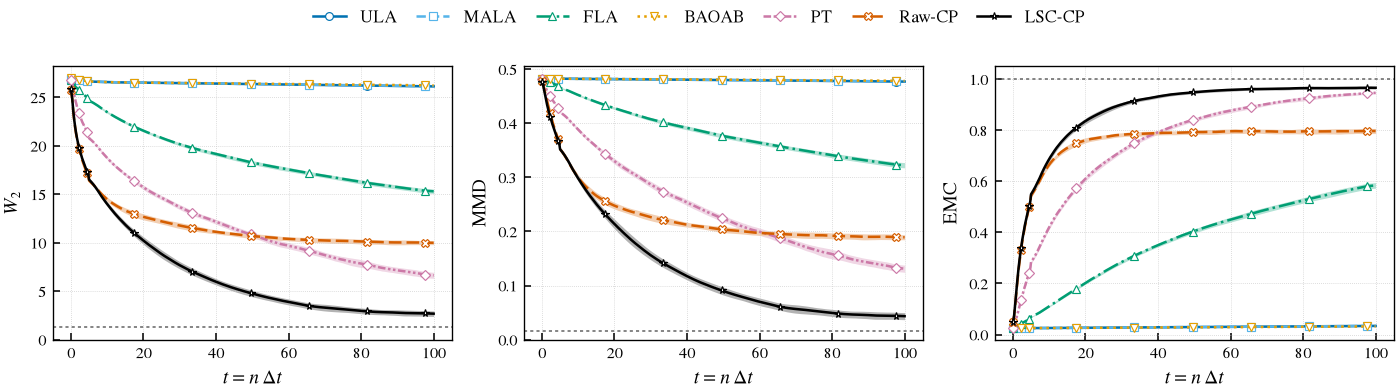

saved: /home/zheyuanlai/levy-sampling/JCP_experiments/figures/mog40/mog40_metrics.{png,pdf}


saved per-metric log-y figures: ['W2', 'TV', 'MMD', 'e_F', 'basin_rel_max', 'KSD'] x {t, nfe, wallclock}


split-Rhat(occ0) | final NFE:
  ULA        : Rhat=1.794  NFE=6e+08
  MALA       : Rhat=1.787  NFE=1.2e+09
  FLA        : Rhat=1.718  NFE=6e+08
  BAOAB      : Rhat=1.897  NFE=6e+08
  PT         : Rhat=1.521  NFE=3.6e+09
  CP         : Rhat=1.123  NFE=6e+08
  LSC-CP     : Rhat=1.133  NFE=6e+08
  LSC-CP-RA  : Rhat=1.198  NFE=1.08e+10


In [8]:
from src.plotting import metric_single
from src.runner import convergence_report
# plotted-method policy: figures show ONE LSC-CP line -- the practical
# estimator advocated for this experiment (multi-atom if run, else single-atom
# RA, else exact), labeled "LSC-CP". When the exact-score run is also in the
# matrix (E1/E2 dual-run) it stays in the CSV as the estimator-agreement
# record but is not drawn: the estimators agree within the seed band, and a
# second black line only clutters / stretches the cost axes.
PLOT_LSC = next((m for m in ("LSC-CP-MA", "LSC-CP-RA", "LSC-CP")
                 if m in RUN_METHODS), "LSC-CP")
PLOT_RAW = "CP" if "CP" in RUN_METHODS else "CP-RA"
PLOT_METHODS = [m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                if m in RUN_METHODS] + [PLOT_RAW, PLOT_LSC]
PLOT_LABELS = {PLOT_RAW: "Raw-CP", PLOT_LSC: "LSC-CP"}
print("plotted methods:", PLOT_METHODS, " labels:", PLOT_LABELS)

fig = metric_grid(rows, os.path.join(FIGURES, EXPERIMENT + "_metrics"),
                  metrics=("W2", "MMD", "EMC"), floors=floors,
                  emc_target=emc_target, methods=PLOT_METHODS,
                  label_overrides=PLOT_LABELS)
print("saved:", os.path.join(FIGURES, EXPERIMENT + "_metrics") + ".{png,pdf}")

# per-metric log-y single figures on t / NFE / wall-clock axes (all curves start
# at the shared n=0 point; linear x so t=0 / NFE=0 is representable; the cost
# axes are truncated at the largest non-LSC terminal x -- metric_single's
# xmax_mode="baselines" -- so the 10-30x-per-step LSC-CP curve cannot squeeze
# every baseline against the y-axis)
_present = set().union(*[set(r) for r in rows])
_single = [m for m in ("W2", "TV", "MMD", "e_F", "basin_rel_max", "KSD",
                       "TV_density", "W2_10d") if m in _present]
for _m in _single:
    for _axis in ("t", "nfe", "wallclock"):
        metric_single(rows, _m, os.path.join(FIGURES, f"{EXPERIMENT}_{_m}_{_axis}"),
                      xaxis=_axis, floors=floors, methods=PLOT_METHODS,
                      emc_target=emc_target, label_overrides=PLOT_LABELS,
                      show=False)
print("saved per-metric log-y figures:", _single, "x {t, nfe, wallclock}")

# cross-seed convergence: rank-normalized split-Rhat on the slow basin-0
# occupancy (each seed a chain); metastable targets that trap seeds -> Rhat >> 1
# (reported for ALL run methods, including any undrawn exact-score run)
conv = convergence_report(rows, RUN_METHODS, cfg.seeds)
print("split-Rhat(occ0) | final NFE:")
for _mth, _d in conv.items():
    print(f"  {_mth:11s}: Rhat={_d['split_rhat']:.3f}  NFE={_d['final_nfe']:.3g}")

In [9]:
# terminal exact-W2 spot check (Hungarian, 500-point subsample, 2D only)
gen_h = torch.Generator(device=DEV); gen_h.manual_seed(202)
ref_sub = exp.ref_sample(2500, gen_h)
from src.metrics import hungarian_w2
hungarian = {m: hungarian_w2(method_info[m]["final_positions_seed0"], ref_sub, m=500)
             for m in RUN_METHODS}
print("Hungarian W2:", {k: round(v, 3) for k, v in hungarian.items()})
ts_path = os.path.join(RESULTS, "metrics_timeseries.csv")
write_timeseries_csv(rows, ts_path)
summary_metrics = MAIN_METRICS + ["nonfinite_frac"]
summary = write_summary_csv(rows, RUN_METHODS, cfg.seeds, summary_metrics,
                            method_info, floors, os.path.join(RESULTS, "summary.csv"))

# plot policy recomputed here (not inherited from the figures cell) so the
# manifest is self-contained even if cells are run out of order; it makes
# results/<exp>/ sufficient to regenerate every figure with no GPU
# (scripts/replot_figures.py reads it).
_plot_lsc = next((m for m in ("LSC-CP-MA", "LSC-CP-RA", "LSC-CP")
                  if m in RUN_METHODS), "LSC-CP")
_plot_raw = "CP" if "CP" in RUN_METHODS else "CP-RA"
manifest = dict(
    experiment=EXPERIMENT,
    config=dict(d=cfg.d, N=cfg.n_particles, T=cfg.T, dt0=cfg.dt, dt=dt_final,
                beta=cfg.beta, eps=cfg.eps, lam=cfg.lam, seeds=list(cfg.seeds),
                n_checkpoints=C.N_CHECKPOINTS, warmup_steps=C.N_WARMUP_STEPS,
                batched_seeds=True),
    emc_target=float(emc_target),
    p_star=[float(v) for v in exp.p_star.cpu()],
    plot=dict(
        methods=[m for m in ("ULA", "MALA", "FLA", "BAOAB", "PT")
                 if m in RUN_METHODS] + [_plot_raw, _plot_lsc],
        label_overrides={_plot_raw: "Raw-CP", _plot_lsc: "LSC-CP"}),
    quadrature=dict(chosen=CHOSEN_QUAD, table=quad_table),
    dt_refinement=[{k: (str(v) if isinstance(v, tuple) else v) for k, v in row.items()}
                   for row in dt_table],
    pt_ladder={k: v for k, v in ladder_info.items()},
    certificate=cert_report,
    bias_floors=floors,
    barrier_verification=barrier_report,
    method_info={m: {k: v for k, v in mi.items() if isinstance(v, (int, float))}
                 for m, mi in method_info.items()},
    hardware=hardware_manifest(),
    hungarian_w2_terminal=hungarian,
)
write_manifest(os.path.join(RESULTS, "manifest.json"), **manifest)
print("wrote", ts_path)
from IPython.display import display
display(pd.read_csv(os.path.join(RESULTS, "summary.csv")).round(5))

Hungarian W2: {'ULA': 36.954, 'MALA': 36.917, 'FLA': 22.597, 'BAOAB': 37.131, 'PT': 10.387, 'CP': 15.339, 'LSC-CP': 5.988, 'LSC-CP-RA': 7.303}


wrote /home/zheyuanlai/levy-sampling/JCP_experiments/results/mog40/metrics_timeseries.csv


,method,EMC_mean,EMC_std,MMD_mean,MMD_std,TV_mean,TV_std,V_evals_per_step,W2_mean,W2_std,...,jump_count_mean,m_clip_fraction,mala_accept,nonfinite_frac_mean,nonfinite_frac_std,pt_swap_accept,score_quad_evals_per_step,time_to_threshold_TV,wallclock_mean_s,wallclock_std_s
0,ULA,0.03379,0.00048,0.47687,0.00039,0.91634,0.00268,0.0,26.11726,0.02408,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,2.25418,0.0
1,MALA,0.03362,0.00048,0.47711,0.00043,0.91673,0.00320,60000.0,26.13578,0.02856,...,NaN,NaN,0.99994,0.0,0.0,NaN,0.0,inf,5.61868,0.0
2,FLA,0.58740,0.01044,0.32134,0.00467,0.43585,0.00682,0.0,15.24710,0.21367,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,2.86789,0.0
3,BAOAB,0.03166,0.00060,0.47827,0.00053,0.93006,0.00446,0.0,26.22791,0.03228,...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,inf,2.44769,0.0
4,PT,0.94801,0.00457,0.12932,0.00686,0.14138,0.00672,180000.0,6.54290,0.33530,...,NaN,NaN,0.99855,0.0,0.0,0.26317,0.0,inf,11.60784,0.0
5,CP,0.79727,0.00823,0.18893,0.00440,0.28555,0.00886,0.0,9.98113,0.19095,...,0.01005,NaN,NaN,0.0,0.0,NaN,0.0,inf,3.62491,0.0
6,LSC-CP,0.98772,0.00258,0.04823,0.00684,0.06369,0.00749,0.0,2.83008,0.33882,...,0.01005,0.0,NaN,0.0,0.0,NaN,0.0,62.59,2771.75603,0.0
7,LSC-CP-RA,0.96714,0.00489,0.04278,0.00640,0.10300,0.00908,1020000.0,2.65216,0.26288,...,0.01002,0.0,NaN,0.0,0.0,NaN,0.0,inf,27.57233,0.0
